### WS 2020/21 <span style="float: right;">GET Lab<br />Paderborn University</span><br />
## <center>Digital Image Processing I<br /><br />Task Sheet 13</center>
---

### Overview

The objective of this exercise is to study full-color image processing. As with the gray-level transformations from chapter 3, color transformations for multispectral (color) images can be modeled as follows:

$$
s_i = T_i(r_i)\hspace{1cm}i=1,2,\dots,n
$$

In this equation, $n$ is the number of component images (normally 3), $r_i$ are the intensity values of the input component images, and $s_i$ are the corresponding intensity values in the output component images. The set of transformations or mapping functions that operate on $r_i$ to compute $s_i$ are denoted $T_i$. The equation is applied individually on each component image, but $T_i$ can be different for each component (therefore the subscript $i$ in $T_i$).

It is therefore not surprising that several techniques from chapter 3 are reused here. 

---

In [1]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

dpi = plt.rcParams['figure.dpi']

# plot image in original size
def plot_img_orig(img):
    fig = plt.figure(figsize = (img.shape[1]/dpi, img.shape[0]/dpi))
    fig.add_axes([0, 0, 1, 1])
    plt.axis('off')
    plt.imshow(img, cmap='gray', vmin=0, vmax=255) # cmap parameter is ignored for RGB(A) data
    plt.show()

#### <span style="color: RoyalBlue; font-weight: bold;">Task 13.1</span> Color Images to Grayscale Images

In principle, there are several methods to create grayscale images based on RGB images (image files are usually in RGB). For the conversion from RGB to HSI, the intensity (which corresponds to the grayscale image) is computed as the mean $I = 1/3 \cdot (R+G+B)$ (see lecture notes). For the conversion from RGB to HSV, the value component is computed as the maximum $\text{V} = \max{(R,G,B)}$ (see last task sheet). The standard method in OpenCV is yet another one: the luminosity function, which considers the spectral sensitivity of human visual perception. In particular, the human eye is most sensitive to yellow-green colors, which is why the green channel gets the highest weight: $I = 0.299 \cdot R + 0.587 \cdot G + 0.114 \cdot B$ (see <a href="https://docs.opencv.org/4.2.0/de/d25/imgproc_color_conversions.html">OpenCV documenation</a>).

Implement / solve the following tasks:
    
1. Read the image *fruits-small.png* as a color image (RGB) and plot it.
2. Read the image *fruits-small.png* as a grayscale image and plot it.
3. Convert the RGB image to HSV and plot the V(alue) channel.
4. Convert the RGB image to <a href="https://docs.opencv.org/4.2.0/de/d25/imgproc_color_conversions.html#color_convert_rgb_lab">`CIE L*a*b` ↗</a> and plot the L(ightness) channel.
5. Compare the results.

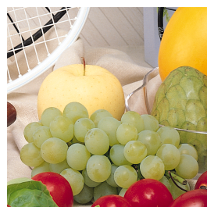

In [5]:
# write your code here
img_bgr = cv2.imread('images/fruits-small.png', 1)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
plot_img_orig(img_rgb)

In [ ]:
img_gray = cv2.imread('images/fruits-small.png', 0)
plot_img_orig(img_gray)

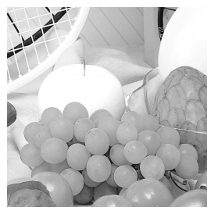

In [6]:
img_hsv = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV)
img_hsv_v = img_hsv[:, :, 2]
plot_img_orig(img_hsv_v)

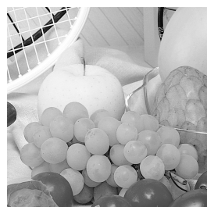

In [8]:
img_cie_lab = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2Lab)
plot_img_orig(img_cie_lab[:, :, 0])

#### <span style="color: RoyalBlue; font-weight: bold;">Task 13.2</span> Intensity Adjustment

The intensity of a HSV image can be adjusted by multiplying only the V channel of this image with a konstant $k \in [0,1]$ so that $s_3 = k r_3$, or by modifying all RGB components in case of a RGB image so that $s_i = k r_i$.

Implement / solve the following tasks:
    
1. Multiply each channel of a RGB image by a given factor (e.g., $k = 0.5$)
2. Apply the corresponding transformation to the HSV image by multiplying only the V channel.
3. Plot and compare the results.

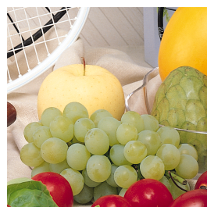

In [9]:
# write your code here
img_bgr = cv2.imread('images/fruits-small.png', 1)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
plot_img_orig(img_rgb)

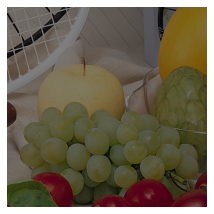

In [10]:
k = 0.5
mod_image = (img_rgb * k).astype(np.uint8)
plot_img_orig(mod_image)

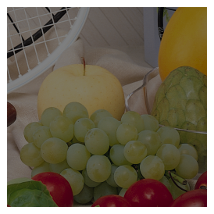

In [19]:
img_bgr2hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
img_bgr2hsv[:, :, 2] = img_bgr2hsv[:, :, 2]*k
img_hsv2rgb = cv2.cvtColor(img_bgr2hsv, cv2.COLOR_HSV2RGB)
plot_img_orig(img_hsv2rgb)

#### <span style="color: RoyalBlue; font-weight: bold;">Task 13.3</span> Color Complements

The hues at opposite sides of the color circle (or of the HSV plane from the last task sheet) are called color complements. A practical application is the production of negatives in traditional photography. To produce a photograph, the negative is put on transparent material (e.g., plastic). Then, light is sent trough the negative on white sensitized paper. In order to get a high response on the paper, e.g., to produce black, high exposure is required so that the corresponding negative is white there.

For color images, the color complements can be computed by either inverting all RGB channels, or by inverting the V channel (or I in case of HSI) *and* taking the oppostite color in the H channel when using the HSV color space.

Implement / solve the following tasks:
    
1. Implement a function to compute the color complement of a given RGB image.
2. Test the function and plot the result (e.g., using *baboon-small.png*).

In [20]:
# write your code here

# compute color complement of a given rgb (or bgr) image
def color_complement(img):
    res = np.zeros(img.shape, dtype=np.uint8) # init (rows x cols x 3) image with zeros
    
    res[:, :, 0] = 255-img[:, :, 0]
    res[:, :, 1] = 255-img[:, :, 1]
    res[:, :, 2] = 255-img[:, :, 2]
    
    # return result (color complement image)
    return res

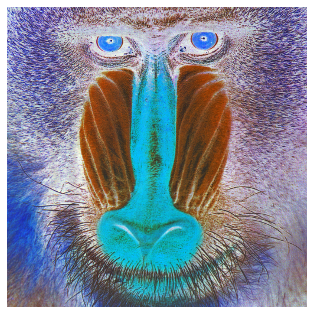

In [22]:
img = cv2.imread('images/baboon-small.png')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plot_img_orig(color_complement(img))

#### <span style="color: RoyalBlue; font-weight: bold;">Task 13.4</span> Color Slicing

The objective of color slicing is to highlight a specific range of colors for image segmentation purposes. Colors of interest can be segmented so that they stand out from the background. The segmented regions can then be used for further processing. In principal, color slicing can be seen as an extension of gray-level slicing (see task sheet 4).

In the RGB color space, it is common to use a (hyper-)cube or (hyper-)sphere to define the colors of interest: all colors inside the cube or sphere are adopted, while all colors outside are mapped to a nonprominent neutral color (e.g., middle gray so that $R = G = B = 128$).

For a (hyper-)sphere with the radius $R_0$ and the center components $a_j$ (corresponding to the prototypical color), this idea can be formalized as follows (note that the formula just uses the Euclidean distance squared):

$
s_i = \left\{
\begin{array}{ll}
128, & \text{if } \sum_{j=0}^n (r_j - a_j)^2 > R_0^2 \\
r_i, & \textrm{otherwise} \\
\end{array}
\right.
$

Implement / solve the following tasks:
    
1. Implement a function to slice a given RGB image around a given prototypical color using a sphere with the radius $R_0$.
2. Test the function by slicing the red nose of the baboon in the test image *baboon-small.png*.

In [23]:
# write your code here

# slice given rgb image around given prototypical color using a sphere with the radius r
def color_slicing(img, color, r):
    res = img.copy() # create copy of original image
    
    for row in range(img.shape[0]):
        for col in range(img.shape[1]):
            # compute the squared distance
            d = (img[row,col,0] - color[0])**2 + (img[row,col,1] - color[1])**2 + (img[row,col,2] - color[2])**2
            
            if (d > (r*r)):
                res[row,col,:] = 128
        
    # return result (color complement image)
    return res

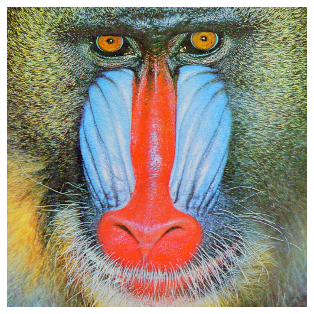

In [24]:
img_bgr = cv2.imread('images/baboon-small.png', 1)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
plot_img_orig(img_rgb)

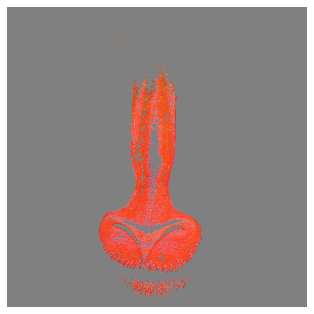

In [27]:
color = np.array([237, 86, 73]) # prototypical color (use a color picker to define it)
r = 60 # radius of the sphere
img_rgb_sliced = color_slicing(img_rgb, color, r)
plot_img_orig(img_rgb_sliced)

#### <span style="color: RoyalBlue; font-weight: bold;">Task 13.5</span> Color Corrections

Color corrections can be used for adjusting the brightness and contrast of an image to provide maximum detail over a suitable range of intensities, while the colors are not changed. In the RGB (and CMY(K)) color space, all channels can be mapped with the same transformation function. Several transformation functions can be used; even the gamma correction (see task sheet 4) can be diverted for this purpose. Another option (not considered here) is to use histogram equalization, which can be used to process the V channel in the HSV color space.

Implement / solve the following tasks:
    
1. Read the image *monarch-dark.png* as a color image (RGB) and plot it.
2. Apply a color correction to this image (use the same transformation function for each RGB channel) by reusing the gamma correction from task sheet 4.
3. Plot the transformation function and the corrected image.

In [28]:
# write your code here

# gamma correction from task sheet 4 (slightly modified)
def gamma_correction(img, gamma, c=255):
    rows, cols = img.shape # image size
    res = np.zeros(shape=[rows, cols], dtype=np.uint8)
    
    # iterate over the image
    for row in range(rows):
        for col in range(cols):
            res[row, col] = 255 * ((img[row, col] / 255) ** gamma)
            
    # return gamma corrected image
    return res
            
# ...

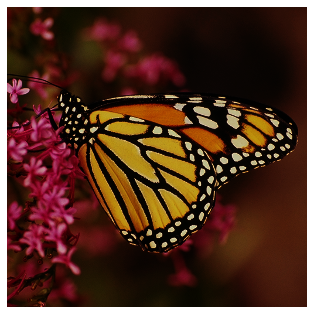

In [29]:
img_bgr = cv2.imread('images/monarch-dark.png', 1)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
plot_img_orig(img_rgb)

In [30]:
img_r, img_g, img_b = cv2.split(img_rgb)

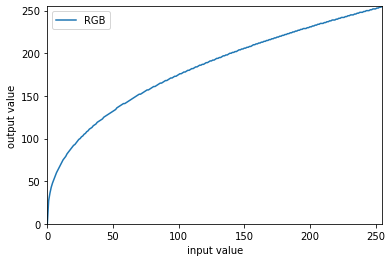

In [31]:
# plot the transformation function, 1-d, for visualization purpose.
val_in = np.arange(256).reshape(256, 1) # create column array with values [0, 255], reshape for plotting
val_out = gamma_correction(val_in, 0.4)

plt.plot(val_in, val_out, label="RGB")
plt.xlim([0, 255])
plt.ylim([0, 255])
plt.xlabel("input value")
plt.ylabel("output value")
plt.legend()
plt.show()

Result:


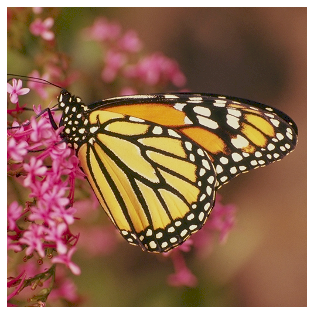

In [32]:
# gamma correction for each channel 
img_r = gamma_correction(img_r, 0.4)
img_g = gamma_correction(img_g, 0.4)
img_b = gamma_correction(img_b, 0.4)

# merge the channels
res = cv2.merge([img_r, img_g, img_b])
print("Result:")
plot_img_orig(res)

#### <span style="color: RoyalBlue; font-weight: bold;">Task 13.6</span> Sharpening (and Smoothing) 

Sharpening (and smoothing) of color images can also be achieved by processing each RGB channel individually, or by processing only the V channel in the HSV color space. In this example, a color image should be sharpened using the Laplacian with the help of a Laplacian filter mask.

To enhance the channels of the original image, the Laplacian image $\nabla^2 r_i$ can be added to the original $r_i$. Recall that if the filter mask has a negative center coefficient, the Laplacian is subtracted to obtain the sharpened result, otherwise it is added:

$$
s_i =
\begin{cases}
r_i-\nabla^2 r_i &\ \text{if the center coefficient is negative}\\
r_i+\nabla^2 r_i &\ \text{if the center coefficient is positive}\\
\end{cases}
$$

Implement / solve the following tasks:
    
1. Read the image *peppers-small.png* as a color image (RGB) and plot it.
2. Sharpen this image using the given Laplacian mask for each RGB channel and plot the result.

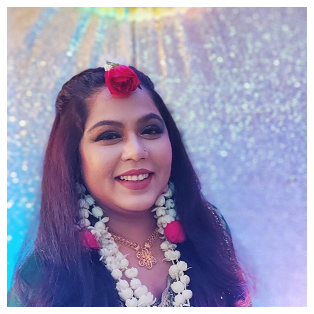

In [53]:
# write your code here
#img_bgr = cv2.imread('images/peppers-small.png', 1)
img_bgr = cv2.imread('images/raida.png', 1)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
plot_img_orig(img_rgb)

In [54]:
# create Laplacian mask
laplace = np.array([[0, 1, 0], [1, -4, 1], [0, 1, 0]])
img_r, img_g, img_b = cv2.split(img_rgb)
res_r = cv2.filter2D(img_r, cv2.CV_64F, laplace)
res_g = cv2.filter2D(img_g, cv2.CV_64F, laplace)
res_b = cv2.filter2D(img_b, cv2.CV_64F, laplace)

In [55]:
res_r_comb = img_r - res_r
res_g_comb = img_g - res_g
res_b_comb = img_b - res_b

In [56]:
res_r_comb_n = cv2.normalize(res_r_comb, None, 0, 255, cv2.NORM_MINMAX)
res_g_comb_n = cv2.normalize(res_g_comb, None, 0, 255, cv2.NORM_MINMAX)
res_b_comb_n = cv2.normalize(res_b_comb, None, 0, 255, cv2.NORM_MINMAX)

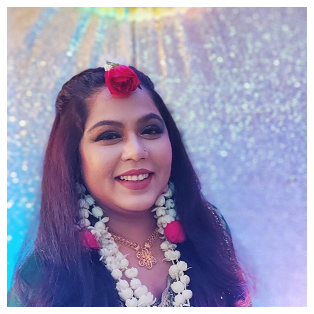

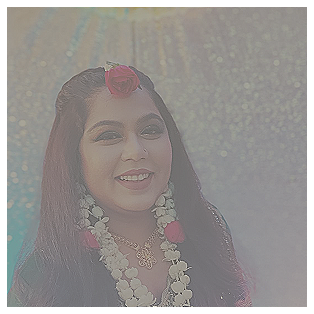

In [57]:
res = cv2.merge([res_r_comb_n, res_g_comb_n, res_b_comb_n]).astype('uint8')
plot_img_orig(img_rgb)
plot_img_orig(res)

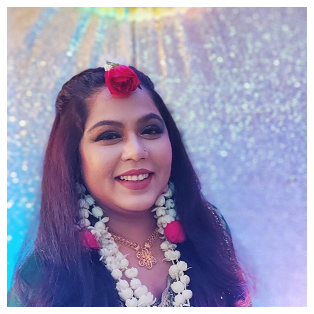

In [49]:
img_bgr = cv2.imread('images/raida.png', 1)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
plot_img_orig(img_rgb)

In [50]:
laplace = np.array([[0, 1, 0], [1, -4, 1], [0, 1, 0]])
img_r, img_g, img_b = cv2.split(img_rgb)
img_r_f = cv2.filter2D(img_r, cv2.CV_64F, laplace)
img_g_f = cv2.filter2D(img_g, cv2.CV_64F, laplace)
img_b_f = cv2.filter2D(img_b, cv2.CV_64F, laplace)

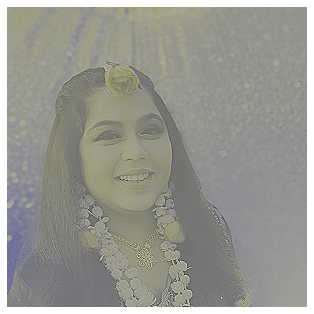

In [52]:
img_r_s = img_r - img_r_f
img_g_s = img_g - img_g_f
img_b_s = img_b - img_b_f

img_r_s_n = cv2.normalize(img_r_s, None, 0, 255, cv2.NORM_MINMAX)
img_g_s_n = cv2.normalize(img_r_s, None, 0, 255, cv2.NORM_MINMAX)
img_b_s_n = cv2.normalize(img_b_s, None, 0, 255, cv2.NORM_MINMAX)

res = cv2.merge([img_r_s_n, img_g_s_n, img_b_s_n]).astype('uint8')
plot_img_orig(res)

#### <span style="color: RoyalBlue; font-weight: bold;">Task 13.7</span> Color Segmentation in HSV

Segmentation is the process of partitioning an image into regions. Color slicing can already be seen as a variant of segmentation, especially if the extracted image parts are labeled as *one* region. This region can then be represented as a binary mask.

In the HSV color space, the S(aturation) channel can be thresholded to get a binary mask to isolate the regions of interest, because regions with low saturation are often irrelevant.

Implement / solve the following tasks:
    
1. Read the image *valsequillo-reservoir.png* as a color image (RGB) and plot it.
2. Convert this image to HSV and plot each channel.
3. Compute a binary mask which segments regions with water based on the S channel. The OpenCV function <a href="https://docs.opencv.org/4.2.0/d7/d1b/group__imgproc__misc.html#gae8a4a146d1ca78c626a53577199e9c57">`threshold` ↗</a> can be used for this purpose.
4. Mark the regions with water blue and plot the result.

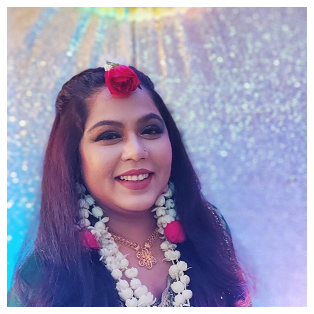

In [68]:
# write your code here
#img = cv2.imread('images/valsequillo-reservoir.png',1)
img = cv2.imread('images/raida.png',1)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plot_img_orig(img)

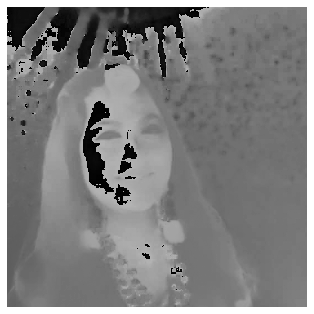

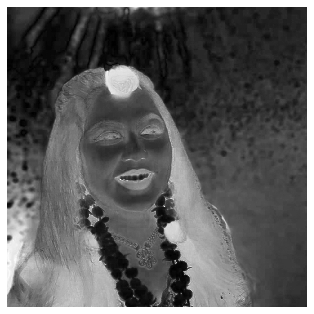

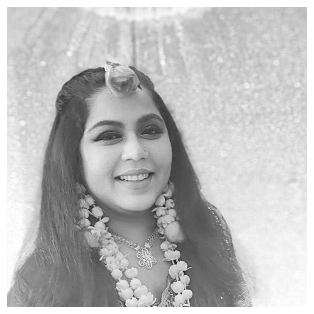

In [69]:
img_hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)

plot_img_orig(img_hsv[:, :, 0])
plot_img_orig(img_hsv[:, :, 1])
plot_img_orig(img_hsv[:, :, 2])

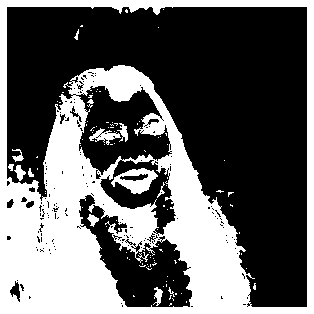

In [70]:
ret, img_s_thresh = cv2.threshold(img_hsv[:, :, 1], 90, 255, cv2.THRESH_BINARY)
plot_img_orig(img_s_thresh)

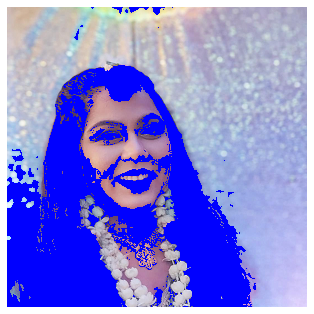

In [75]:
indices = np.where(img_s_thresh > 0)
img_hsv[indices[0], indices[1], 0] = 120
img_hsv[indices[0], indices[1], 1] = 255
img_hsv[indices[0], indices[1], 2] = 255

res = cv2.cvtColor(img_hsv, cv2.COLOR_HSV2RGB)
plot_img_orig(res)
#